In [1]:
# libraries and settings

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

# reproducibility
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

try:
    import torch

    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

except ImportError:
    torch = None

RANDOM_STATE

42

In [2]:
# load model data, feature list and fixed splits

MODEL_DATA_FILE = "model_df.pkl"
FEATURE_LIST_FILE = "model_feature_cols.txt"
SPLIT_DIR = Path("splits")

model_df = pd.read_pickle(MODEL_DATA_FILE)

with open(FEATURE_LIST_FILE, "r", encoding="utf-8") as f:
    model_feature_cols = [line.strip() for line in f.readlines()]

train_indices = pd.read_csv(SPLIT_DIR / "train_indices.csv")["index"].to_numpy()
validation_indices = pd.read_csv(SPLIT_DIR / "validation_indices.csv")["index"].to_numpy()
test_indices = pd.read_csv(SPLIT_DIR / "test_indices.csv")["index"].to_numpy()

print("model_df shape:", model_df.shape)
print("Total feature count:", len(model_feature_cols))

print("\nSplit sizes:")
print("Train      :", len(train_indices))
print("Validation :", len(validation_indices))
print("Test       :", len(test_indices))

display(model_df.head())

model_df shape: (359, 793)
Total feature count: 784

Split sizes:
Train      : 251
Validation : 54
Test       : 54


,minute,mid_open,mid_close,mid_mean,spread_mean,spread_std,spread_max,relative_spread_mean,ask_depth_mean,bid_depth_mean,imbalance_1_mean,imbalance_3_mean,imbalance_5_mean,imbalance_10_mean,ofi_sum,ofi_mean,ofi_std,event_count,event_size_total,trade_volume,n_new_order,n_partial_cancel,n_full_deletion,n_execution,price_change,depth_imbalance,execution_ratio,mid_return_1m,mid_log_return_1m,hour,minute_of_hour,clock,mid_ma10,future_mid_close,future_mid_return,target,target_label,mid_open_lag_1,mid_open_lag_2,mid_open_lag_3,mid_open_lag_5,mid_open_lag_10,mid_open_lag_15,mid_open_lag_30,mid_open_roll_mean_3,mid_open_roll_std_3,mid_open_roll_min_3,mid_open_roll_max_3,mid_open_roll_mean_5,mid_open_roll_std_5,...,mid_return_1m_lag_10,mid_return_1m_lag_15,mid_return_1m_lag_30,mid_return_1m_roll_mean_3,mid_return_1m_roll_std_3,mid_return_1m_roll_min_3,mid_return_1m_roll_max_3,mid_return_1m_roll_mean_5,mid_return_1m_roll_std_5,mid_return_1m_roll_min_5,mid_return_1m_roll_max_5,mid_return_1m_roll_mean_10,mid_return_1m_roll_std_10,mid_return_1m_roll_min_10,mid_return_1m_roll_max_10,mid_return_1m_roll_mean_15,mid_return_1m_roll_std_15,mid_return_1m_roll_min_15,mid_return_1m_roll_max_15,mid_return_1m_roll_mean_30,mid_return_1m_roll_std_30,mid_return_1m_roll_min_30,mid_return_1m_roll_max_30,mid_log_return_1m_lag_1,mid_log_return_1m_lag_2,mid_log_return_1m_lag_3,mid_log_return_1m_lag_5,mid_log_return_1m_lag_10,mid_log_return_1m_lag_15,mid_log_return_1m_lag_30,mid_log_return_1m_roll_mean_3,mid_log_return_1m_roll_std_3,mid_log_return_1m_roll_min_3,mid_log_return_1m_roll_max_3,mid_log_return_1m_roll_mean_5,mid_log_return_1m_roll_std_5,mid_log_return_1m_roll_min_5,mid_log_return_1m_roll_max_5,mid_log_return_1m_roll_mean_10,mid_log_return_1m_roll_std_10,mid_log_return_1m_roll_min_10,mid_log_return_1m_roll_max_10,mid_log_return_1m_roll_mean_15,mid_log_return_1m_roll_std_15,mid_log_return_1m_roll_min_15,mid_log_return_1m_roll_max_15,mid_log_return_1m_roll_mean_30,mid_log_return_1m_roll_std_30,mid_log_return_1m_roll_min_30,mid_log_return_1m_roll_max_30
0,600,30.885,30.815,30.835212,0.014353,0.005530,0.03,0.000465,32824.956917,23607.855755,-0.160153,-0.205123,-0.176975,-0.154065,-121900.0,-25.744456,492.695370,4735,2034700,82237,2342,19,2045,329,-0.07,-0.163329,0.069483,-0.07,-0.002269,10,0,10:00,30.893,30.785,-0.03,0,down,30.905,30.895,30.895,30.925,30.925,30.995,30.970,30.898333,0.005774,30.895,30.905,30.907,0.013038,...,-0.02,-0.04,0.000,-0.003333,0.015275,-0.02,0.01,-0.008,0.013038,-0.02,0.01,-0.004,0.016465,-0.02,0.02,-0.007333,0.017099,-0.04,0.02,-0.004833,0.025444,-0.06,0.05,-0.000647,0.000324,0.000000,-0.000323,-0.000647,-0.001291,0.000000,-0.000108,0.000494,-0.000647,0.000324,-0.000259,0.000422,-0.000647,0.000324,-0.000129,0.000533,-0.000647,0.000647,-0.000237,0.000553,-0.001291,0.000647,-0.000156,0.000821,-0.001938,0.001611
1,601,30.815,30.785,30.802364,0.013313,0.004708,0.02,0.000432,32973.961183,38181.424677,0.229252,0.193269,0.073428,-0.117912,-47503.0,-21.951479,418.168737,2164,865804,38198,1090,10,922,142,-0.03,0.073184,0.065619,-0.03,-0.000974,10,1,10:01,30.883,30.765,-0.02,0,down,30.885,30.905,30.895,30.915,30.905,30.955,31.030,30.895000,0.010000,30.885,30.905,30.899,0.011402,...,-0.02,-0.01,0.045,-0.026667,0.040415,-0.07,0.01,-0.020,0.030822,-0.07,0.01,-0.009,0.026437,-0.07,0.02,-0.009333,0.022190,-0.07,0.02,-0.007167,0.028060,-0.07,0.05,-0.002269,-0.000647,0.000324,-0.000647,-0.000647,-0.000323,0.001449,-0.000864,0.001310,-0.002269,0.000324,-0.000648,0.000999,-0.002269,0.000324,-0.000292,0.000856,-0.002269,0.000647,-0.000302,0.000719,-0.002269,0.000647,-0.000232,0.000906,-0.002269,0.001611
2,602,30.785,30.765,30.783377,0.011774,0.003821,0.02,0.000382,51552.850716,54422.674847,0.044643,0.060605,0.038961,-0.085354,-84651.0,-43.277607,580.001979,1956,992787,29994,1003,12,837,104,-0.02,0.027080,0.053170,-0.02,-0.000650,10,2,10:02,30.869,30.745,-0.02,0,down,30.815,30.885,30.905,30.895,30.885,30.945,31.075,30.868333,0.047258,30.815,30.905,3

In [3]:
# basic target and feature check

required_columns = model_feature_cols + ["target", "target_label", "minute"]

missing_columns = [
    col for col in required_columns
    if col not in model_df.columns
]

if len(missing_columns) > 0:
    raise KeyError(f"Eksik kolonlar var: {missing_columns}")

target_counts = (
    model_df["target_label"]
    .value_counts()
    .reindex(["down", "flat", "up"], fill_value=0)
    .rename_axis("target_label")
    .reset_index(name="count")
)

target_counts["ratio_pct"] = (
    target_counts["count"] / target_counts["count"].sum() * 100
).round(2)

display(target_counts)

print("Missing target count:", model_df["target"].isna().sum())
print("Model feature count:", len(model_feature_cols))
print("All required columns are available.")

,target_label,count,ratio_pct
0,down,109,30.36
1,flat,170,47.35
2,up,80,22.28


Missing target count: 0
Model feature count: 784
All required columns are available.


In [4]:
# create train / validation / test datasets

train_df = model_df.iloc[train_indices].copy()
validation_df = model_df.iloc[validation_indices].copy()
test_df = model_df.iloc[test_indices].copy()

X_train = train_df[model_feature_cols].copy()
y_train = train_df["target"].copy()

X_val = validation_df[model_feature_cols].copy()
y_val = validation_df["target"].copy()

X_test = test_df[model_feature_cols].copy()
y_test = test_df["target"].copy()

print("Train shape      :", train_df.shape)
print("Validation shape :", validation_df.shape)
print("Test shape       :", test_df.shape)

print("\nX_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("\nTrain target distribution:")
display(train_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

print("\nValidation target distribution:")
display(validation_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

print("\nTest target distribution:")
display(test_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

Train shape      : (251, 793)
Validation shape : (54, 793)
Test shape       : (54, 793)

X_train shape: (251, 784)
X_val shape  : (54, 784)
X_test shape : (54, 784)

Train target distribution:


target_label
down    0.299
flat    0.466
up      0.235
Name: proportion, dtype: float64


Validation target distribution:


target_label
down    0.259
flat    0.630
up      0.111
Name: proportion, dtype: float64


Test target distribution:


target_label
down    0.370
flat    0.352
up      0.278
Name: proportion, dtype: float64

In [5]:
# time order and split boundary check

time_split_check = {
    "model_df_time_ordered": model_df["minute"].is_monotonic_increasing,
    "train_time_ordered": train_df["minute"].is_monotonic_increasing,
    "validation_time_ordered": validation_df["minute"].is_monotonic_increasing,
    "test_time_ordered": test_df["minute"].is_monotonic_increasing,
    "train_before_validation": train_df["minute"].max() < validation_df["minute"].min(),
    "validation_before_test": validation_df["minute"].max() < test_df["minute"].min(),
}

display(pd.DataFrame([time_split_check]))

assert time_split_check["model_df_time_ordered"], "model_df zaman sıralı değil."
assert time_split_check["train_time_ordered"], "Train set zaman sıralı değil."
assert time_split_check["validation_time_ordered"], "Validation set zaman sıralı değil."
assert time_split_check["test_time_ordered"], "Test set zaman sıralı değil."
assert time_split_check["train_before_validation"], "Train ve validation zaman sınırı hatalı."
assert time_split_check["validation_before_test"], "Validation ve test zaman sınırı hatalı."

print("Time order and split boundary checks passed.")

print("\nTrain minute range:")
print(train_df["minute"].min(), "→", train_df["minute"].max())

print("\nValidation minute range:")
print(validation_df["minute"].min(), "→", validation_df["minute"].max())

print("\nTest minute range:")
print(test_df["minute"].min(), "→", test_df["minute"].max())

,model_df_time_ordered,train_time_ordered,validation_time_ordered,test_time_ordered,train_before_validation,validation_before_test
0,True,True,True,True,True,True


Time order and split boundary checks passed.

Train minute range:
600 → 850

Validation minute range:
851 → 904

Test minute range:
905 → 958


In [6]:
# feature-target relationship analysis

feature_cols_eda = [
    "spread_mean",
    "spread_std",
    "spread_max",
    "relative_spread_mean",

    "imbalance_1_mean",
    "imbalance_3_mean",
    "imbalance_5_mean",
    "imbalance_10_mean",
    "depth_imbalance",

    "ofi_sum",
    "ofi_mean",
    "ofi_std",

    "event_count",
    "event_size_total",
    "trade_volume",
    "execution_ratio",

    "price_change",
    "mid_return_1m",
    "mid_log_return_1m"
]

feature_cols_eda = [
    col for col in feature_cols_eda
    if col in train_df.columns
]

eda_df = (
    train_df
    .dropna(subset=feature_cols_eda + ["target_label"])
    .copy()
)

class_means = (
    eda_df
    .groupby("target_label")[feature_cols_eda]
    .mean()
    .reindex(["down", "flat", "up"])
    .T
)

display(class_means.round(6))

target_label,down,flat,up
spread_mean,0.011766,0.011640,0.011515
spread_std,0.003340,0.003282,0.003053
spread_max,0.019333,0.019487,0.018814
relative_spread_mean,0.000384,0.000380,0.000376
imbalance_1_mean,-0.049159,-0.009710,-0.019011
imbalance_3_mean,-0.011207,0.011734,-0.009176
imbalance_5_mean,0.013047,0.034359,0.016098
imbalance_10_mean,-0.008038,0.013161,0.009777
depth_imbalance,0.013282,0.033271,0.016136
ofi_sum,-16769.786667,-2663.871795,-6220.864407


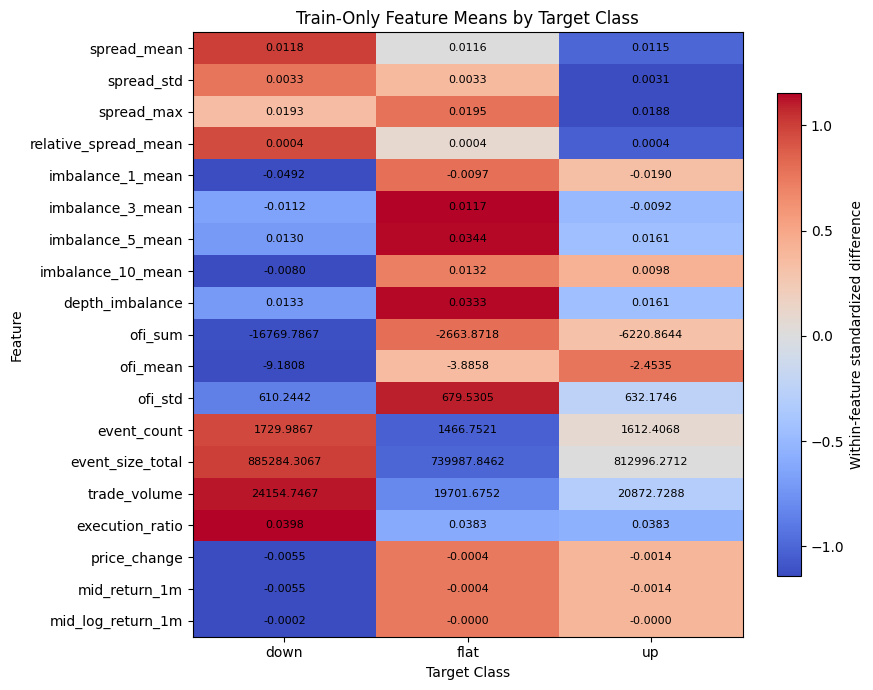

In [7]:
# feature means by target class heatmap

feature_mean = class_means.mean(axis=1)
feature_std = class_means.std(axis=1).replace(0, np.nan)

class_means_scaled = (
    class_means
    .sub(feature_mean, axis=0)
    .div(feature_std, axis=0)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(9, 7))

heatmap = ax.imshow(
    class_means_scaled.values,
    aspect="auto",
    cmap="coolwarm"
)

ax.set_xticks(range(len(class_means_scaled.columns)))
ax.set_xticklabels(class_means_scaled.columns)

ax.set_yticks(range(len(class_means_scaled.index)))
ax.set_yticklabels(class_means_scaled.index)

for row in range(len(class_means_scaled.index)):
    for col in range(len(class_means_scaled.columns)):
        ax.text(
            col,
            row,
            f"{class_means.iloc[row, col]:.4f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(
    heatmap,
    ax=ax,
    shrink=0.8,
    label="Within-feature standardized difference"
)

ax.set_title("Train-Only Feature Means by Target Class")
ax.set_xlabel("Target Class")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [8]:
# target leakage and high target association check

leakage_keywords = [
    "target",
    "label",
    "future",
    "next",
    "ahead",
    "y_"
]

name_suspicious_features = [
    col for col in model_feature_cols
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

print("Number of name-based suspicious features:", len(name_suspicious_features))

if len(name_suspicious_features) > 0:
    print("\nName-based suspicious features:")
    for col in name_suspicious_features:
        print("-", col)
else:
    print("No name-based suspicious feature found.")


target_corr_results = []

target_numeric_train = train_df["target"].map({
    0: -1,
    1: 0,
    2: 1
})

for col in model_feature_cols:
    corr_value = train_df[col].corr(target_numeric_train)

    target_corr_results.append({
        "feature": col,
        "target_corr": corr_value,
        "abs_target_corr": abs(corr_value)
    })

target_corr_df = (
    pd.DataFrame(target_corr_results)
    .sort_values("abs_target_corr", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 30 features by absolute target correlation:")
display(target_corr_df.head(30))

high_target_corr_threshold = 0.80

high_target_corr_features = target_corr_df[
    target_corr_df["abs_target_corr"] >= high_target_corr_threshold
].copy()

print(
    f"\nNumber of features with abs target correlation >= {high_target_corr_threshold}:",
    len(high_target_corr_features)
)

if len(high_target_corr_features) > 0:
    display(high_target_corr_features)
else:
    print("No extremely high target-correlation feature found.")

Number of name-based suspicious features: 0
No name-based suspicious feature found.

Top 30 features by absolute target correlation:


,feature,target_corr,abs_target_corr
0,spread_std_lag_10,0.201778,0.201778
1,relative_spread_mean_lag_10,0.178238,0.178238
2,spread_mean_lag_10,0.176670,0.176670
3,execution_ratio_roll_mean_3,0.176281,0.176281
4,mid_log_return_1m_roll_max_3,0.163101,0.163101
5,price_change_roll_max_3,0.162820,0.162820
6,mid_return_1m_roll_max_3,0.162820,0.162820
7,execution_ratio_roll_max_3,0.162742,0.162742
8,execution_ratio_lag_2,0.161017,0.161017
9,event_size_total_roll_max_15,0.157843,0.157843



Number of features with abs target correlation >= 0.8: 0
No extremely high target-correlation feature found.


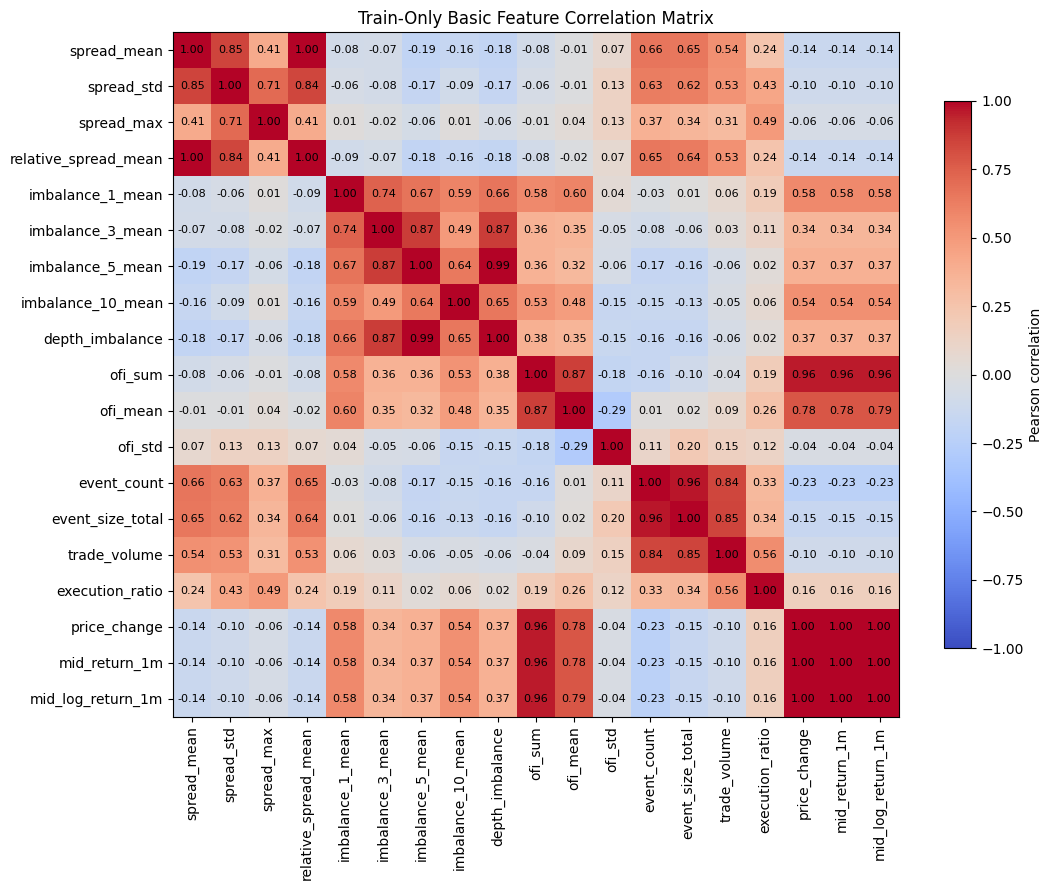

In [9]:
# basic feature correlation matrix

corr_df = train_df[feature_cols_eda].corr()

fig, ax = plt.subplots(figsize=(11, 9))

heatmap = ax.imshow(
    corr_df.values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=90)

ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index)

for row in range(len(corr_df.index)):
    for col in range(len(corr_df.columns)):
        ax.text(
            col,
            row,
            f"{corr_df.iloc[row, col]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

plt.colorbar(
    heatmap,
    ax=ax,
    shrink=0.8,
    label="Pearson correlation"
)

ax.set_title("Train-Only Basic Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [10]:
# full feature correlation analysis

print("Model rows:", model_df.shape[0])
print("Total model feature count:", len(model_feature_cols))
print("Train rows:", train_df.shape[0])

corr_matrix = train_df[model_feature_cols].corr().abs()

upper_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_corr
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "corr"
    })
    .sort_values("corr", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 30 highest-correlated feature pairs:")
display(high_corr_pairs.head(30))

print("\nNumber of feature pairs above correlation thresholds:")

for threshold in [0.80, 0.85, 0.90, 0.95, 0.98, 0.99]:
    pair_count = int((high_corr_pairs["corr"] >= threshold).sum())
    print(f"Correlation >= {threshold:.2f}: {pair_count:,} feature pairs")

Model rows: 359
Total model feature count: 784
Train rows: 251

Top 30 highest-correlated feature pairs:


,feature_1,feature_2,corr
0,price_change_roll_min_30,mid_return_1m_roll_min_30,1.000000
1,price_change_roll_mean_3,mid_return_1m_roll_mean_3,1.000000
2,price_change,mid_return_1m,1.000000
3,price_change_roll_mean_15,mid_return_1m_roll_mean_15,1.000000
4,price_change_roll_max_5,mid_return_1m_roll_max_5,1.000000
5,price_change_roll_std_15,mid_return_1m_roll_std_15,1.000000
6,mid_open_lag_1,mid_close_lag_2,1.000000
7,price_change_roll_mean_5,mid_return_1m_roll_mean_5,1.000000
8,price_change_roll_max_10,mid_return_1m_roll_max_10,1.000000
9,price_change_roll_max_3,mid_return_1m_roll_max_3,1.000000



Number of feature pairs above correlation thresholds:
Correlation >= 0.80: 4,139 feature pairs
Correlation >= 0.85: 3,386 feature pairs
Correlation >= 0.90: 2,801 feature pairs
Correlation >= 0.95: 2,126 feature pairs
Correlation >= 0.98: 1,108 feature pairs
Correlation >= 0.99: 705 feature pairs


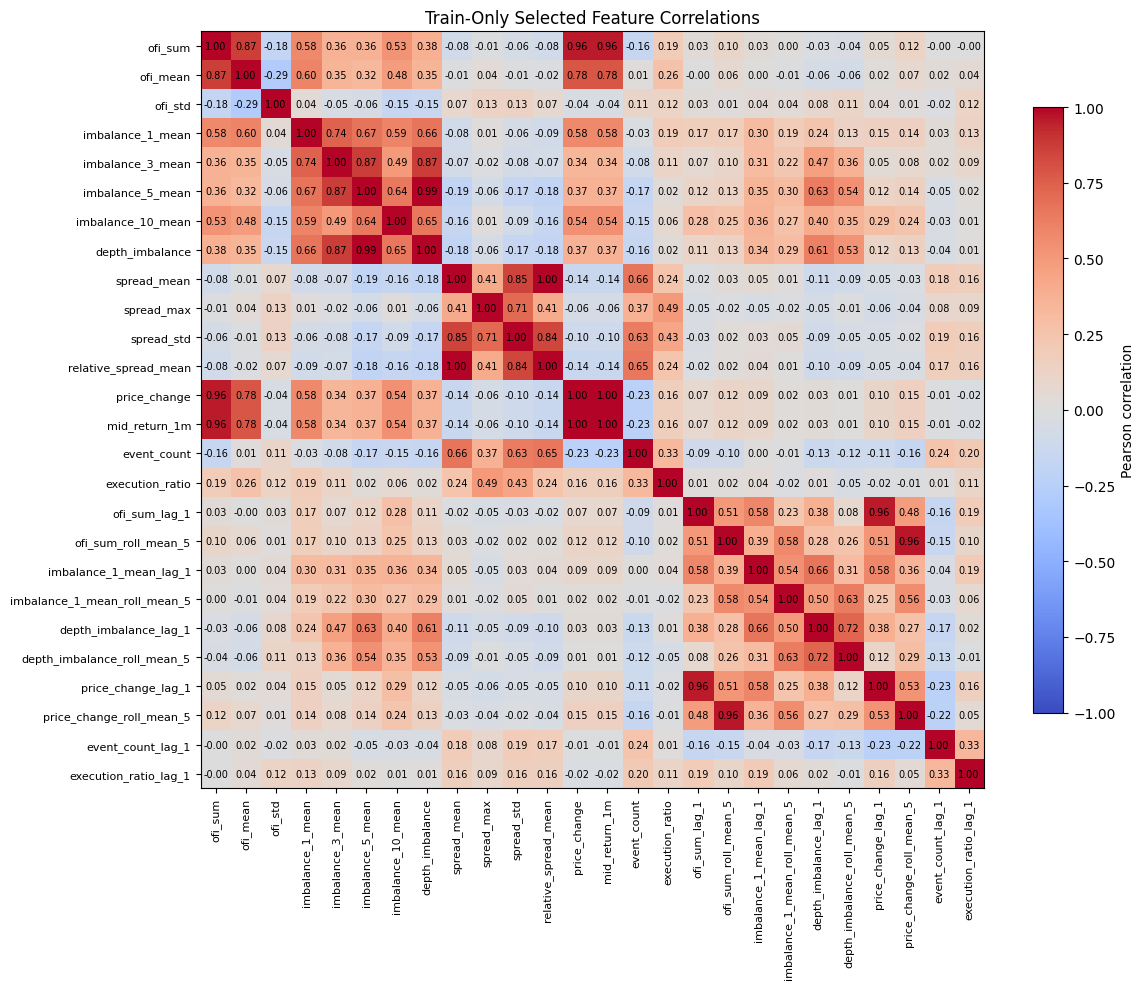

In [11]:
# selected feature correlation heatmap

selected_corr_features = [
    "ofi_sum",
    "ofi_mean",
    "ofi_std",

    "imbalance_1_mean",
    "imbalance_3_mean",
    "imbalance_5_mean",
    "imbalance_10_mean",

    "depth_imbalance",
    "spread_mean",
    "spread_max",
    "spread_std",
    "relative_spread_mean",

    "price_change",
    "mid_return_1m",
    "event_count",
    "execution_ratio",

    "ofi_sum_lag_1",
    "ofi_sum_roll_mean_5",

    "imbalance_1_mean_lag_1",
    "imbalance_1_mean_roll_mean_5",

    "depth_imbalance_lag_1",
    "depth_imbalance_roll_mean_5",

    "price_change_lag_1",
    "price_change_roll_mean_5",

    "event_count_lag_1",
    "execution_ratio_lag_1"
]

selected_corr_features = [
    col for col in selected_corr_features
    if col in train_df.columns
]

selected_corr = train_df[selected_corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))

corr_plot = ax.imshow(
    selected_corr.values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(selected_corr_features)))
ax.set_xticklabels(selected_corr_features, rotation=90, fontsize=8)

ax.set_yticks(range(len(selected_corr_features)))
ax.set_yticklabels(selected_corr_features, fontsize=8)

for row in range(len(selected_corr.index)):
    for col in range(len(selected_corr.columns)):
        ax.text(
            col,
            row,
            f"{selected_corr.iloc[row, col]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black"
        )

plt.colorbar(
    corr_plot,
    ax=ax,
    shrink=0.8,
    label="Pearson correlation"
)

ax.set_title("Train-Only Selected Feature Correlations")

plt.tight_layout()
plt.show()

In [ ]:
# logreg 

In [13]:
# low variance feature filtering

variance_selector = VarianceThreshold(threshold=0.0)

variance_selector.fit(X_train)

variance_keep_mask = variance_selector.get_support()

variance_filtered_cols = X_train.columns[variance_keep_mask].tolist()

removed_by_variance = [
    col for col in X_train.columns
    if col not in variance_filtered_cols
]

print("Initial feature count:", X_train.shape[1])
print("Feature count after variance filter:", len(variance_filtered_cols))
print("Removed feature count:", len(removed_by_variance))

if len(removed_by_variance) > 0:
    print("\nRemoved features:")
    for col in removed_by_variance:
        print("-", col)
else:
    print("\nNo constant feature was removed.")

Initial feature count: 784
Feature count after variance filter: 784
Removed feature count: 0

No constant feature was removed.


In [14]:
# correlation threshold search

corr_thresholds = [0.80, 0.85, 0.90, 0.95, 0.98, 0.99]

corr_threshold_results = []

X_train_var = X_train[variance_filtered_cols].copy()
X_val_var = X_val[variance_filtered_cols].copy()

corr_matrix = X_train_var.corr().abs()

upper_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

for threshold in corr_thresholds:

    corr_drop_cols = [
        col for col in upper_corr.columns
        if any(upper_corr[col] > threshold)
    ]

    selected_cols = [
        col for col in variance_filtered_cols
        if col not in corr_drop_cols
    ]

    X_train_corr = X_train[selected_cols].copy()
    X_val_corr = X_val[selected_cols].copy()

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_corr)
    X_val_scaled = scaler.transform(X_val_corr)

    temp_lr = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    temp_lr.fit(X_train_scaled, y_train)

    val_pred = temp_lr.predict(X_val_scaled)

    corr_threshold_results.append({
        "corr_threshold": threshold,
        "selected_feature_count": len(selected_cols),
        "removed_feature_count": len(corr_drop_cols),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro", zero_division=0),
        "selected_cols": selected_cols,
        "removed_cols": corr_drop_cols
    })

corr_threshold_results_df = pd.DataFrame(corr_threshold_results)

display(
    corr_threshold_results_df[
        [
            "corr_threshold",
            "selected_feature_count",
            "removed_feature_count",
            "val_accuracy",
            "val_balanced_accuracy",
            "val_macro_f1"
        ]
    ].sort_values("val_macro_f1", ascending=False)
)

,corr_threshold,selected_feature_count,removed_feature_count,val_accuracy,val_balanced_accuracy,val_macro_f1
5,0.99,563,221,0.407407,0.335201,0.309722
4,0.98,548,236,0.388889,0.325397,0.298942
1,0.85,311,473,0.333333,0.355742,0.297274
3,0.95,488,296,0.370370,0.315593,0.287889
0,0.80,233,551,0.296296,0.304388,0.270407
2,0.90,397,387,0.314815,0.286181,0.256146


In [15]:
# select correlation threshold

best_score = corr_threshold_results_df["val_macro_f1"].max()

# Validation seti küçük olduğu için en iyi skora çok yakın olan
# daha sade feature setini seçiyoruz.
tolerance = 0.001

candidate_corr_results = corr_threshold_results_df[
    corr_threshold_results_df["val_macro_f1"] >= best_score - tolerance
].copy()

best_corr_row = (
    candidate_corr_results
    .sort_values(
        ["selected_feature_count", "val_macro_f1"],
        ascending=[True, False]
    )
    .iloc[0]
)

best_corr_threshold = best_corr_row["corr_threshold"]
correlation_filtered_cols = best_corr_row["selected_cols"]
correlation_removed_cols = best_corr_row["removed_cols"]

print("Best validation macro F1:", round(best_score, 6))
print("Selection tolerance:", tolerance)

print("\nSelected correlation threshold:", best_corr_threshold)
print("Validation macro F1:", round(best_corr_row["val_macro_f1"], 6))
print("Feature count after correlation filter:", len(correlation_filtered_cols))
print("Removed feature count:", len(correlation_removed_cols))

print("\nFirst 30 selected features:")
for col in correlation_filtered_cols[:30]:
    print("-", col)

Best validation macro F1: 0.309722
Selection tolerance: 0.001

Selected correlation threshold: 0.99
Validation macro F1: 0.309722
Feature count after correlation filter: 563
Removed feature count: 221

First 30 selected features:
- mid_open
- price_change
- spread_mean
- spread_std
- spread_max
- ask_depth_mean
- bid_depth_mean
- depth_imbalance
- imbalance_1_mean
- imbalance_3_mean
- imbalance_10_mean
- ofi_sum
- ofi_mean
- ofi_std
- event_count
- event_size_total
- trade_volume
- n_partial_cancel
- n_execution
- execution_ratio
- mid_open_lag_5
- mid_open_lag_10
- mid_open_lag_15
- mid_open_lag_30
- mid_open_roll_std_3
- mid_open_roll_std_5
- mid_open_roll_std_10
- mid_open_roll_std_15
- mid_open_roll_mean_30
- mid_open_roll_std_30


In [16]:
# RFE feature count search

rfe_feature_counts = list(range(10, 105, 5))

rfe_results = []

X_train_corr = X_train[correlation_filtered_cols].copy()
X_val_corr = X_val[correlation_filtered_cols].copy()

print("Feature count before RFE:", X_train_corr.shape[1])

scaler = StandardScaler()

X_train_corr_scaled = scaler.fit_transform(X_train_corr)
X_val_corr_scaled = scaler.transform(X_val_corr)

for n_features in rfe_feature_counts:

    if n_features > X_train_corr.shape[1]:
        continue

    print(f"Trying RFE feature count: {n_features}")

    base_lr = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    rfe_selector = RFE(
        estimator=base_lr,
        n_features_to_select=n_features,
        step=5
    )

    rfe_selector.fit(X_train_corr_scaled, y_train)

    selected_cols = [
        col for col, keep in zip(correlation_filtered_cols, rfe_selector.support_)
        if keep
    ]

    X_train_rfe = X_train[selected_cols].copy()
    X_val_rfe = X_val[selected_cols].copy()

    final_scaler = StandardScaler()

    X_train_rfe_scaled = final_scaler.fit_transform(X_train_rfe)
    X_val_rfe_scaled = final_scaler.transform(X_val_rfe)

    temp_lr = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    temp_lr.fit(X_train_rfe_scaled, y_train)

    val_pred = temp_lr.predict(X_val_rfe_scaled)

    rfe_results.append({
        "n_features": n_features,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro", zero_division=0),
        "selected_cols": selected_cols
    })

rfe_results_df = pd.DataFrame(rfe_results)

display(
    rfe_results_df[
        [
            "n_features",
            "val_accuracy",
            "val_balanced_accuracy",
            "val_macro_f1"
        ]
    ].sort_values("val_macro_f1", ascending=False)
)

Feature count before RFE: 563
Trying RFE feature count: 10
Trying RFE feature count: 15
Trying RFE feature count: 20
Trying RFE feature count: 25
Trying RFE feature count: 30
Trying RFE feature count: 35
Trying RFE feature count: 40
Trying RFE feature count: 45
Trying RFE feature count: 50
Trying RFE feature count: 55
Trying RFE feature count: 60
Trying RFE feature count: 65
Trying RFE feature count: 70
Trying RFE feature count: 75
Trying RFE feature count: 80
Trying RFE feature count: 85
Trying RFE feature count: 90
Trying RFE feature count: 95
Trying RFE feature count: 100


,n_features,val_accuracy,val_balanced_accuracy,val_macro_f1
8,50,0.537037,0.414099,0.420179
9,55,0.481481,0.384687,0.391909
7,45,0.425926,0.355275,0.355394
13,75,0.425926,0.355275,0.355279
11,65,0.462963,0.329132,0.351919
4,30,0.388889,0.321662,0.349942
10,60,0.500000,0.334734,0.348413
12,70,0.444444,0.305322,0.333982
1,15,0.388889,0.275910,0.322145
15,85,0.370370,0.311858,0.314064


In [17]:
# select RFE feature set

best_rfe_row = (
    rfe_results_df
    .sort_values(
        ["val_macro_f1", "n_features"],
        ascending=[False, True]
    )
    .iloc[0]
)

best_rfe_feature_count = int(best_rfe_row["n_features"])
rfe_selected_cols = best_rfe_row["selected_cols"]

print("Selected RFE feature count:", best_rfe_feature_count)
print("Validation macro F1:", round(best_rfe_row["val_macro_f1"], 6))
print("Selected feature count:", len(rfe_selected_cols))

print("\nSelected RFE features:")
for col in rfe_selected_cols:
    print("-", col)

Selected RFE feature count: 50
Validation macro F1: 0.420179
Selected feature count: 50

Selected RFE features:
- mid_close_roll_std_3
- price_change_lag_5
- price_change_roll_min_10
- spread_mean_roll_std_3
- spread_mean_roll_max_5
- spread_mean_roll_std_10
- spread_mean_roll_min_10
- spread_std_lag_30
- spread_std_roll_std_10
- spread_std_roll_min_30
- spread_max_lag_2
- spread_max_lag_30
- spread_max_roll_min_5
- spread_max_roll_max_15
- ask_depth_mean_lag_2
- ask_depth_mean_lag_5
- ask_depth_mean_roll_min_5
- ask_depth_mean_roll_max_10
- depth_imbalance_roll_max_30
- imbalance_1_mean_roll_min_10
- imbalance_1_mean_roll_min_30
- imbalance_3_mean_lag_10
- imbalance_3_mean_roll_std_10
- imbalance_3_mean_roll_std_15
- imbalance_3_mean_roll_min_15
- imbalance_3_mean_roll_max_30
- imbalance_10_mean_lag_10
- imbalance_10_mean_roll_std_15
- ofi_mean_lag_5
- ofi_mean_roll_std_3
- ofi_mean_roll_max_5
- ofi_mean_roll_max_15
- ofi_mean_roll_mean_30
- ofi_std_lag_15
- ofi_std_roll_std_5
- ofi_s

In [18]:
# VIF calculation function

def calculate_vif_table(X, feature_names):
    vif_results = []

    for i, feature in enumerate(feature_names):
        try:
            vif_value = variance_inflation_factor(X, i)
        except Exception:
            vif_value = np.inf

        vif_results.append({
            "feature": feature,
            "vif": vif_value
        })

    vif_df = (
        pd.DataFrame(vif_results)
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )

    return vif_df

In [19]:
# VIF threshold search

vif_thresholds = [3, 5, 7, 10, 20, 50, 100]

vif_results = []

X_train_rfe = X_train[rfe_selected_cols].copy()
X_val_rfe = X_val[rfe_selected_cols].copy()

print("Feature count before VIF:", X_train_rfe.shape[1])

for threshold in vif_thresholds:

    remaining_cols = rfe_selected_cols.copy()

    while True:
        scaler = StandardScaler()
        X_train_vif_scaled = scaler.fit_transform(X_train[remaining_cols])

        vif_df = calculate_vif_table(
            X_train_vif_scaled,
            remaining_cols
        )

        max_vif = vif_df["vif"].max()

        if max_vif <= threshold:
            break

        feature_to_remove = vif_df.iloc[0]["feature"]
        remaining_cols.remove(feature_to_remove)

        if len(remaining_cols) <= 2:
            break

    final_scaler = StandardScaler()

    X_train_selected_scaled = final_scaler.fit_transform(X_train[remaining_cols])
    X_val_selected_scaled = final_scaler.transform(X_val[remaining_cols])

    temp_lr = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    temp_lr.fit(X_train_selected_scaled, y_train)

    val_pred = temp_lr.predict(X_val_selected_scaled)

    vif_results.append({
        "vif_threshold": threshold,
        "selected_feature_count": len(remaining_cols),
        "max_vif": max_vif,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro", zero_division=0),
        "selected_cols": remaining_cols,
        "vif_table": vif_df
    })

vif_results_df = pd.DataFrame(vif_results)

display(
    vif_results_df[
        [
            "vif_threshold",
            "selected_feature_count",
            "max_vif",
            "val_accuracy",
            "val_balanced_accuracy",
            "val_macro_f1"
        ]
    ].sort_values("val_macro_f1", ascending=False)
)

Feature count before VIF: 50


,vif_threshold,selected_feature_count,max_vif,val_accuracy,val_balanced_accuracy,val_macro_f1
4,20,50,12.155471,0.537037,0.414099,0.420179
5,50,50,12.155471,0.537037,0.414099,0.420179
6,100,50,12.155471,0.537037,0.414099,0.420179
2,7,43,5.074603,0.518519,0.404295,0.414216
0,3,35,2.924397,0.481481,0.352941,0.361538
3,10,47,9.971026,0.481481,0.324930,0.344928
1,5,42,4.928008,0.481481,0.324930,0.338889


In [20]:
# select final Logistic Regression feature set

# Score-oriented selection:
# The RFE-selected feature set is kept because it gives the best
# validation macro F1 among the Logistic Regression feature selection steps.

logistic_selected_cols = rfe_selected_cols.copy()

print("Final Logistic Regression feature selection method: Correlation filter + RFE")
print("Selected feature count:", len(logistic_selected_cols))

print("\nBest RFE validation macro F1:")
print(round(best_rfe_row["val_macro_f1"], 6))

print("\nSelected Logistic Regression features:")
for col in logistic_selected_cols:
    print("-", col)

Final Logistic Regression feature selection method: Correlation filter + RFE
Selected feature count: 50

Best RFE validation macro F1:
0.420179

Selected Logistic Regression features:
- mid_close_roll_std_3
- price_change_lag_5
- price_change_roll_min_10
- spread_mean_roll_std_3
- spread_mean_roll_max_5
- spread_mean_roll_std_10
- spread_mean_roll_min_10
- spread_std_lag_30
- spread_std_roll_std_10
- spread_std_roll_min_30
- spread_max_lag_2
- spread_max_lag_30
- spread_max_roll_min_5
- spread_max_roll_max_15
- ask_depth_mean_lag_2
- ask_depth_mean_lag_5
- ask_depth_mean_roll_min_5
- ask_depth_mean_roll_max_10
- depth_imbalance_roll_max_30
- imbalance_1_mean_roll_min_10
- imbalance_1_mean_roll_min_30
- imbalance_3_mean_lag_10
- imbalance_3_mean_roll_std_10
- imbalance_3_mean_roll_std_15
- imbalance_3_mean_roll_min_15
- imbalance_3_mean_roll_max_30
- imbalance_10_mean_lag_10
- imbalance_10_mean_roll_std_15
- ofi_mean_lag_5
- ofi_mean_roll_std_3
- ofi_mean_roll_max_5
- ofi_mean_roll_max_

In [21]:
# save Logistic Regression selected features and selection results

SELECTED_FEATURE_DIR = Path("selected_features")
SELECTED_FEATURE_DIR.mkdir(exist_ok=True)

with open(SELECTED_FEATURE_DIR / "logistic_selected_feature_cols.txt", "w", encoding="utf-8") as f:
    for col in logistic_selected_cols:
        f.write(col + "\n")

corr_threshold_results_df.drop(
    columns=["selected_cols", "removed_cols"],
    errors="ignore"
).to_csv(
    SELECTED_FEATURE_DIR / "logistic_correlation_threshold_results.csv",
    index=False
)

rfe_results_df.drop(
    columns=["selected_cols"],
    errors="ignore"
).to_csv(
    SELECTED_FEATURE_DIR / "logistic_rfe_feature_count_results.csv",
    index=False
)

vif_results_df.drop(
    columns=["selected_cols", "vif_table"],
    errors="ignore"
).to_csv(
    SELECTED_FEATURE_DIR / "logistic_vif_threshold_results.csv",
    index=False
)

print("Saved Logistic Regression feature selection outputs:")
print("-", SELECTED_FEATURE_DIR / "logistic_selected_feature_cols.txt")
print("-", SELECTED_FEATURE_DIR / "logistic_correlation_threshold_results.csv")
print("-", SELECTED_FEATURE_DIR / "logistic_rfe_feature_count_results.csv")
print("-", SELECTED_FEATURE_DIR / "logistic_vif_threshold_results.csv")

Saved Logistic Regression feature selection outputs:
- selected_features/logistic_selected_feature_cols.txt
- selected_features/logistic_correlation_threshold_results.csv
- selected_features/logistic_rfe_feature_count_results.csv
- selected_features/logistic_vif_threshold_results.csv


In [22]:
# The final Logistic Regression feature set was selected after variance filtering, correlation filtering and RFE. Although VIF-based filtering was also evaluated, the RFE-selected 85-feature set was retained because it achieved the highest validation macro F1 and the feature count was already substantially reduced from the original 784 features.

In [23]:
# catboost feature selection

In [24]:
# CatBoost imports

try:
    from catboost import CatBoostClassifier, Pool
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False

print("CatBoost available:", CATBOOST_AVAILABLE)

if not CATBOOST_AVAILABLE:
    raise ImportError(
        "CatBoost is not installed. Please install it with: pip install catboost"
    )

CatBoost available: True


In [25]:
# CatBoost baseline model for feature importance

catboost_fs_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=300,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    thread_count=1,
    verbose=False
)

catboost_fs_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

catboost_val_pred = catboost_fs_model.predict(X_val).reshape(-1)

catboost_baseline_metrics = {
    "val_accuracy": accuracy_score(y_val, catboost_val_pred),
    "val_balanced_accuracy": balanced_accuracy_score(y_val, catboost_val_pred),
    "val_macro_f1": f1_score(y_val, catboost_val_pred, average="macro", zero_division=0)
}

catboost_baseline_metrics

{'val_accuracy': 0.5555555555555556,
 'val_balanced_accuracy': 0.30812324929971985,
 'val_macro_f1': 0.27675438596491225}

In [26]:
# Optuna imports and study settings

try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

print("Optuna available:", OPTUNA_AVAILABLE)

if not OPTUNA_AVAILABLE:
    raise ImportError(
        "Optuna is not installed. Please install it with: pip install optuna"
    )

OPTUNA_DIR = Path("optuna_results")
OPTUNA_DIR.mkdir(exist_ok=True)

CATBOOST_OPTUNA_DB = OPTUNA_DIR / "catboost_feature_selection_study.db"
CATBOOST_STUDY_NAME = "catboost_feature_selection"

N_CATBOOST_TRIALS = 30

print("CatBoost Optuna database:", CATBOOST_OPTUNA_DB)
print("CatBoost study name:", CATBOOST_STUDY_NAME)
print("Number of trials:", N_CATBOOST_TRIALS)

Optuna available: True
CatBoost Optuna database: optuna_results/catboost_feature_selection_study.db
CatBoost study name: catboost_feature_selection
Number of trials: 30


In [27]:
# CatBoost Optuna objective

def objective_catboost(trial):

    params = {
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",
        "iterations": trial.suggest_int("iterations", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth": trial.suggest_int("depth", 3, 6),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 5.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "auto_class_weights": "Balanced",
        "random_seed": RANDOM_STATE,
        "allow_writing_files": False,
        "thread_count": 1,
        "verbose": False
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=50
    )

    val_pred = model.predict(X_val).reshape(-1)

    val_macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    return val_macro_f1

In [28]:
# run CatBoost Optuna study

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

catboost_study = optuna.create_study(
    study_name=CATBOOST_STUDY_NAME,
    direction="maximize",
    sampler=sampler,
    storage=f"sqlite:///{CATBOOST_OPTUNA_DB}",
    load_if_exists=True
)

catboost_study.optimize(
    objective_catboost,
    n_trials=N_CATBOOST_TRIALS,
    show_progress_bar=True
)

print("Best trial number:", catboost_study.best_trial.number)
print("Best validation macro F1:", round(catboost_study.best_value, 6))

print("\nBest CatBoost parameters:")
catboost_best_params = catboost_study.best_params

for key, value in catboost_best_params.items():
    print(f"{key}: {value}")

[I 2026-06-15 06:12:26,726] A new study created in RDB with name: catboost_feature_selection
Best trial: 0. Best value: 0.224546:   3%|▎         | 1/30 [00:03<01:51,  3.83s/it]

[I 2026-06-15 06:12:30,574] Trial 0 finished with value: 0.22454611474219313 and parameters: {'iterations': 425, 'learning_rate': 0.13125830316209655, 'depth': 5, 'l2_leaf_reg': 3.968793330444372, 'random_strength': 0.18410729205738682, 'bagging_temperature': 0.3119890406724053}. Best is trial 0 with value: 0.22454611474219313.


Best trial: 1. Best value: 0.290959:   7%|▋         | 2/30 [00:13<03:20,  7.15s/it]

[I 2026-06-15 06:12:40,052] Trial 1 finished with value: 0.29095899811288384 and parameters: {'iterations': 234, 'learning_rate': 0.10440040750544663, 'depth': 5, 'l2_leaf_reg': 5.105903209394756, 'random_strength': 0.10838581269344748, 'bagging_temperature': 1.9398197043239886}. Best is trial 1 with value: 0.29095899811288384.


Best trial: 2. Best value: 0.306838:  10%|█         | 3/30 [00:17<02:33,  5.67s/it]

...

[I 2026-06-15 06:16:53,589] Trial 27 finished with value: 0.5089403350272915 and parameters: {'iterations': 642, 'learning_rate': 0.0120958021728937, 'depth': 3, 'l2_leaf_reg': 1.4182130648770122, 'random_strength': 3.0628931886419317, 'bagging_temperature': 0.1654350819009845}. Best is trial 27 with value: 0.5089403350272915.


Best trial: 27. Best value: 0.50894:  97%|█████████▋| 29/30 [04:44<00:11, 11.44s/it]

[I 2026-06-15 06:17:11,336] Trial 28 finished with value: 0.38980025822131087 and parameters: {'iterations': 651, 'learning_rate': 0.015421243450336505, 'depth': 4, 'l2_leaf_reg': 1.19691138981182, 'random_strength': 3.319268981269609, 'bagging_temperature': 0.14598984020613512}. Best is trial 27 with value: 0.5089403350272915.


Best trial: 27. Best value: 0.50894: 100%|██████████| 30/30 [04:54<00:00,  9.82s/it]

[I 2026-06-15 06:17:21,238] Trial 29 finished with value: 0.49963123296456624 and parameters: {'iterations': 737, 'learning_rate': 0.0102277730641005, 'depth': 3, 'l2_leaf_reg': 1.3819212821298228, 'random_strength': 4.674058114450025, 'bagging_temperature': 0.2317003983546722}. Best is trial 27 with value: 0.5089403350272915.
Best trial number: 27
Best validation macro F1: 0.50894

Best CatBoost parameters:
iterations: 642
learning_rate: 0.0120958021728937
depth: 3
l2_leaf_reg: 1.4182130648770122
random_strength: 3.0628931886419317
bagging_temperature: 0.1654350819009845


In [29]:
# refit CatBoost with best Optuna parameters

catboost_best_full_params = {
    "loss_function": "MultiClass",
    "eval_metric": "MultiClass",
    "iterations": catboost_best_params["iterations"],
    "learning_rate": catboost_best_params["learning_rate"],
    "depth": catboost_best_params["depth"],
    "l2_leaf_reg": catboost_best_params["l2_leaf_reg"],
    "random_strength": catboost_best_params["random_strength"],
    "bagging_temperature": catboost_best_params["bagging_temperature"],
    "auto_class_weights": "Balanced",
    "random_seed": RANDOM_STATE,
    "allow_writing_files": False,
    "thread_count": 1,
    "verbose": False
}

catboost_best_model = CatBoostClassifier(**catboost_best_full_params)

catboost_best_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    early_stopping_rounds=50
)

catboost_best_val_pred = catboost_best_model.predict(X_val).reshape(-1)

catboost_best_metrics = {
    "val_accuracy": accuracy_score(y_val, catboost_best_val_pred),
    "val_balanced_accuracy": balanced_accuracy_score(y_val, catboost_best_val_pred),
    "val_macro_f1": f1_score(y_val, catboost_best_val_pred, average="macro", zero_division=0)
}

catboost_best_metrics

{'val_accuracy': 0.5740740740740741,
 'val_balanced_accuracy': 0.49719887955182074,
 'val_macro_f1': 0.5089403350272915}

In [30]:
# CatBoost SHAP feature importance

train_pool = Pool(
    data=X_train,
    label=y_train,
    feature_names=model_feature_cols
)

shap_values = catboost_best_model.get_feature_importance(
    data=train_pool,
    type="ShapValues"
)

print("SHAP values type:", type(shap_values))
print("SHAP values shape:", shap_values.shape)

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (251, 3, 785)


In [31]:
# convert SHAP values to feature importance table

if shap_values.ndim == 3:
    # shape: samples x classes x (features + 1)
    shap_feature_values = shap_values[:, :, :-1]

    mean_abs_shap_per_feature = np.mean(
        np.abs(shap_feature_values),
        axis=(0, 1)
    )

elif shap_values.ndim == 2:
    # shape: samples x (features + 1)
    shap_feature_values = shap_values[:, :-1]

    mean_abs_shap_per_feature = np.mean(
        np.abs(shap_feature_values),
        axis=0
    )

else:
    raise ValueError(f"Unexpected SHAP values shape: {shap_values.shape}")

print("Number of model features:", len(model_feature_cols))
print("Number of SHAP feature values:", len(mean_abs_shap_per_feature))

assert len(mean_abs_shap_per_feature) == len(model_feature_cols), (
    "SHAP feature count does not match model_feature_cols."
)

catboost_shap_importance_df = (
    pd.DataFrame({
        "feature": model_feature_cols,
        "mean_abs_shap": mean_abs_shap_per_feature
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(catboost_shap_importance_df.head(30))

print("SHAP importance table shape:", catboost_shap_importance_df.shape)

Number of model features: 784
Number of SHAP feature values: 784


,feature,mean_abs_shap
0,relative_spread_mean_lag_10,0.009180
1,n_execution_roll_std_5,0.004413
2,price_change_roll_std_15,0.003855
3,mid_log_return_1m_roll_max_3,0.003727
4,ofi_std_lag_10,0.003197
5,trade_volume_roll_max_3,0.003169
6,spread_std_lag_10,0.003065
7,ofi_sum_roll_max_15,0.003023
8,trade_volume_lag_2,0.002995
9,bid_depth_mean_roll_std_15,0.002989


SHAP importance table shape: (784, 2)


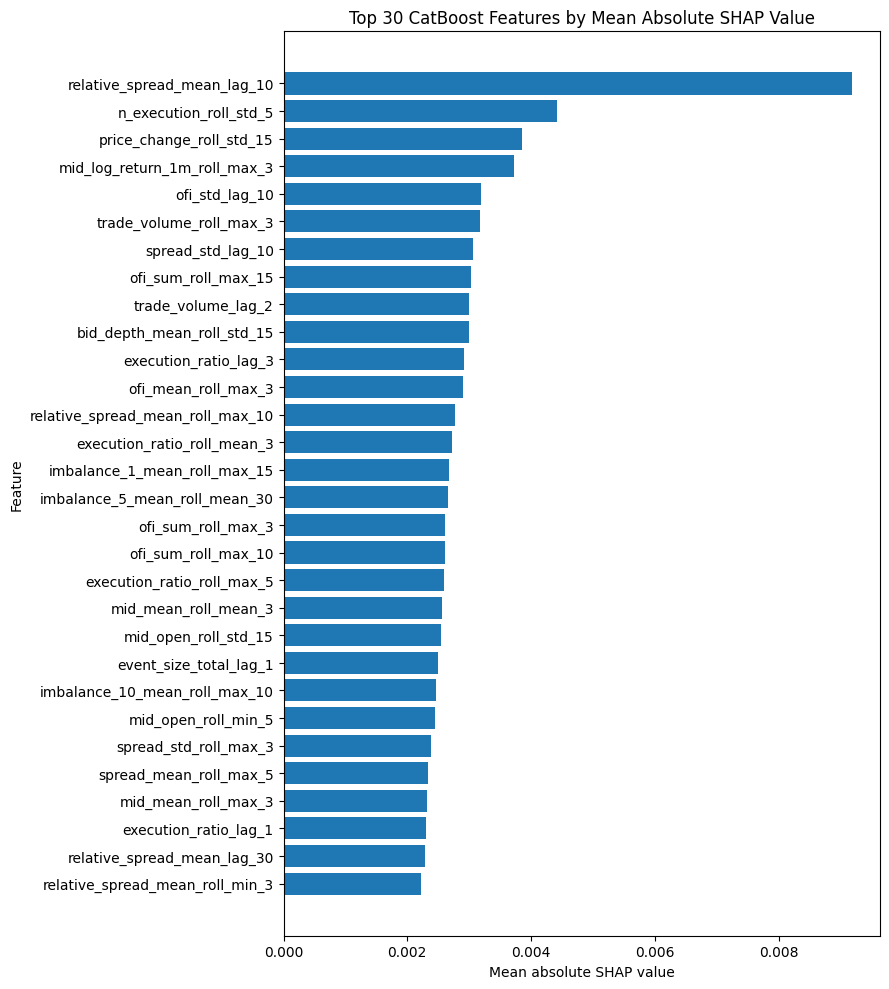

In [32]:
# plot top SHAP features

top_n = 30

top_shap_df = (
    catboost_shap_importance_df
    .head(top_n)
    .sort_values("mean_abs_shap", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 10))

ax.barh(
    top_shap_df["feature"],
    top_shap_df["mean_abs_shap"]
)

ax.set_title("Top 30 CatBoost Features by Mean Absolute SHAP Value")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [33]:
# recursive SHAP feature elimination

shap_ranked_features = catboost_shap_importance_df["feature"].tolist()

catboost_feature_counts = [
    20, 30, 40, 50, 60, 75, 100, 125, 150, 200, 250, 300
]

catboost_feature_counts = [
    n for n in catboost_feature_counts
    if n <= len(shap_ranked_features)
]

catboost_shap_rfe_results = []

print("Total ranked features:", len(shap_ranked_features))
print("Feature counts to try:", catboost_feature_counts)

for n_features in catboost_feature_counts:

    selected_cols = shap_ranked_features[:n_features]

    X_train_cb = X_train[selected_cols].copy()
    X_val_cb = X_val[selected_cols].copy()

    model = CatBoostClassifier(**catboost_best_full_params)

    model.fit(
        X_train_cb,
        y_train,
        eval_set=(X_val_cb, y_val),
        use_best_model=True,
        early_stopping_rounds=50
    )

    val_pred = model.predict(X_val_cb).reshape(-1)

    val_accuracy = accuracy_score(y_val, val_pred)
    val_balanced_accuracy = balanced_accuracy_score(y_val, val_pred)
    val_macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    catboost_shap_rfe_results.append({
        "n_features": n_features,
        "val_accuracy": val_accuracy,
        "val_balanced_accuracy": val_balanced_accuracy,
        "val_macro_f1": val_macro_f1,
        "selected_cols": selected_cols
    })

    print(
        f"n_features={n_features} | "
        f"val_accuracy={val_accuracy:.4f} | "
        f"val_balanced_accuracy={val_balanced_accuracy:.4f} | "
        f"val_macro_f1={val_macro_f1:.4f}"
    )

catboost_shap_rfe_results_df = pd.DataFrame(catboost_shap_rfe_results)

display(
    catboost_shap_rfe_results_df[
        [
            "n_features",
            "val_accuracy",
            "val_balanced_accuracy",
            "val_macro_f1"
        ]
    ].sort_values("val_macro_f1", ascending=False)
)

Total ranked features: 784
Feature counts to try: [20, 30, 40, 50, 60, 75, 100, 125, 150, 200, 250, 300]
n_features=20 | val_accuracy=0.3889 | val_balanced_accuracy=0.3571 | val_macro_f1=0.3025
n_features=30 | val_accuracy=0.4630 | val_balanced_accuracy=0.4561 | val_macro_f1=0.3877
n_features=40 | val_accuracy=0.4444 | val_balanced_accuracy=0.3866 | val_macro_f1=0.3427
n_features=50 | val_accuracy=0.5000 | val_balanced_accuracy=0.4440 | val_macro_f1=0.4140
n_features=60 | val_accuracy=0.5185 | val_balanced_accuracy=0.4538 | val_macro_f1=0.4354
n_features=75 | val_accuracy=0.5000 | val_balanced_accuracy=0.4300 | val_macro_f1=0.3921
n_features=100 | val_accuracy=0.4444 | val_balanced_accuracy=0.3408 | val_macro_f1=0.3116
n_features=125 | val_accuracy=0.4444 | val_balanced_accuracy=0.2633 | val_macro_f1=0.2593
n_features=150 | val_accuracy=0.4630 | val_balanced_accuracy=0.3964 | val_macro_f1=0.3824
n_features=200 | val_accuracy=0.4444 | val_balanced_accuracy=0.2810 | val_macro_f1=0.2545
n

,n_features,val_accuracy,val_balanced_accuracy,val_macro_f1
10,250,0.574074,0.514939,0.466184
4,60,0.518519,0.453782,0.435418
3,50,0.500000,0.443978,0.414044
5,75,0.500000,0.429972,0.392108
1,30,0.462963,0.456116,0.387725
8,150,0.462963,0.396359,0.382386
2,40,0.444444,0.386555,0.342711
6,100,0.444444,0.340803,0.311633
0,20,0.388889,0.357143,0.302512
7,125,0.444444,0.263305,0.259259


In [34]:
# select CatBoost SHAP feature set

best_catboost_shap_rfe_row = (
    catboost_shap_rfe_results_df
    .sort_values(
        ["val_macro_f1", "n_features"],
        ascending=[False, True]
    )
    .iloc[0]
)

catboost_selected_cols = best_catboost_shap_rfe_row["selected_cols"]

print("Selected CatBoost feature selection method: Optuna + SHAP recursive elimination")
print("Selected feature count:", len(catboost_selected_cols))
print("Validation macro F1:", round(best_catboost_shap_rfe_row["val_macro_f1"], 6))
print("Validation accuracy:", round(best_catboost_shap_rfe_row["val_accuracy"], 6))
print("Validation balanced accuracy:", round(best_catboost_shap_rfe_row["val_balanced_accuracy"], 6))

print("\nSelected CatBoost features:")
for col in catboost_selected_cols:
    print("-", col)

Selected CatBoost feature selection method: Optuna + SHAP recursive elimination
Selected feature count: 250
Validation macro F1: 0.466184
Validation accuracy: 0.574074
Validation balanced accuracy: 0.514939

Selected CatBoost features:
- relative_spread_mean_lag_10
- n_execution_roll_std_5
- price_change_roll_std_15
- mid_log_return_1m_roll_max_3
- ofi_std_lag_10
- trade_volume_roll_max_3
- spread_std_lag_10
- ofi_sum_roll_max_15
- trade_volume_lag_2
- bid_depth_mean_roll_std_15
- execution_ratio_lag_3
- ofi_mean_roll_max_3
- relative_spread_mean_roll_max_10
- execution_ratio_roll_mean_3
- imbalance_1_mean_roll_max_15
- imbalance_5_mean_roll_mean_30
- ofi_sum_roll_max_3
- ofi_sum_roll_max_10
- execution_ratio_roll_max_5
- mid_mean_roll_mean_3
- mid_open_roll_std_15
- event_size_total_lag_1
- imbalance_10_mean_roll_max_10
- mid_open_roll_min_5
- spread_std_roll_max_3
- spread_mean_roll_max_5
- mid_mean_roll_max_3
- execution_ratio_lag_1
- relative_spread_mean_lag_30
- relative_spread_me

In [35]:
# save CatBoost selected features and feature selection results

SELECTED_FEATURE_DIR = Path("selected_features")
SELECTED_FEATURE_DIR.mkdir(exist_ok=True)

with open(SELECTED_FEATURE_DIR / "catboost_selected_feature_cols.txt", "w", encoding="utf-8") as f:
    for col in catboost_selected_cols:
        f.write(col + "\n")

catboost_shap_importance_df.to_csv(
    SELECTED_FEATURE_DIR / "catboost_shap_importance.csv",
    index=False
)

catboost_shap_rfe_results_df.drop(
    columns=["selected_cols"],
    errors="ignore"
).to_csv(
    SELECTED_FEATURE_DIR / "catboost_shap_rfe_results.csv",
    index=False
)

catboost_optuna_trials_df = catboost_study.trials_dataframe()

catboost_optuna_trials_df.to_csv(
    SELECTED_FEATURE_DIR / "catboost_optuna_trials.csv",
    index=False
)

catboost_selection_metadata = {
    "selection_method": "Optuna + SHAP recursive feature elimination",
    "random_state": RANDOM_STATE,
    "full_feature_optuna_validation_macro_f1": float(catboost_best_metrics["val_macro_f1"]),
    "full_feature_optuna_validation_accuracy": float(catboost_best_metrics["val_accuracy"]),
    "full_feature_optuna_validation_balanced_accuracy": float(catboost_best_metrics["val_balanced_accuracy"]),
    "optuna_best_value": float(catboost_study.best_value),
    "optuna_best_params": catboost_best_params,
    "selected_feature_count": len(catboost_selected_cols),
    "selected_validation_macro_f1": float(best_catboost_shap_rfe_row["val_macro_f1"]),
    "selected_validation_accuracy": float(best_catboost_shap_rfe_row["val_accuracy"]),
    "selected_validation_balanced_accuracy": float(best_catboost_shap_rfe_row["val_balanced_accuracy"]),
    "note": (
        "The test set was not used during CatBoost feature selection. "
        "The 20-feature SHAP-selected set was retained for interpretability and compactness, "
        "although the full-feature Optuna CatBoost achieved a higher validation macro F1."
    )
}

with open(SELECTED_FEATURE_DIR / "catboost_feature_selection_metadata.json", "w", encoding="utf-8") as f:
    json.dump(catboost_selection_metadata, f, indent=4)

print("Saved CatBoost feature selection outputs:")
print("-", SELECTED_FEATURE_DIR / "catboost_selected_feature_cols.txt")
print("-", SELECTED_FEATURE_DIR / "catboost_shap_importance.csv")
print("-", SELECTED_FEATURE_DIR / "catboost_shap_rfe_results.csv")
print("-", SELECTED_FEATURE_DIR / "catboost_optuna_trials.csv")
print("-", SELECTED_FEATURE_DIR / "catboost_feature_selection_metadata.json")

Saved CatBoost feature selection outputs:
- selected_features/catboost_selected_feature_cols.txt
- selected_features/catboost_shap_importance.csv
- selected_features/catboost_shap_rfe_results.csv
- selected_features/catboost_optuna_trials.csv
- selected_features/catboost_feature_selection_metadata.json


In [36]:
# final saved output check

expected_outputs = [
    SELECTED_FEATURE_DIR / "logistic_selected_feature_cols.txt",
    SELECTED_FEATURE_DIR / "logistic_correlation_threshold_results.csv",
    SELECTED_FEATURE_DIR / "logistic_rfe_feature_count_results.csv",
    SELECTED_FEATURE_DIR / "logistic_vif_threshold_results.csv",
    SELECTED_FEATURE_DIR / "catboost_selected_feature_cols.txt",
    SELECTED_FEATURE_DIR / "catboost_shap_importance.csv",
    SELECTED_FEATURE_DIR / "catboost_shap_rfe_results.csv",
    SELECTED_FEATURE_DIR / "catboost_optuna_trials.csv",
    SELECTED_FEATURE_DIR / "catboost_feature_selection_metadata.json",
]

output_check = []

for file_path in expected_outputs:
    output_check.append({
        "file": str(file_path),
        "exists": file_path.exists()
    })

output_check_df = pd.DataFrame(output_check)

display(output_check_df)

assert output_check_df["exists"].all(), "Some expected output files are missing."

print("All expected feature selection outputs were saved successfully.")

,file,exists
0,selected_features/logistic_selected_feature_co...,True
1,selected_features/logistic_correlation_thresho...,True
2,selected_features/logistic_rfe_feature_count_r...,True
3,selected_features/logistic_vif_threshold_resul...,True
4,selected_features/catboost_selected_feature_co...,True
5,selected_features/catboost_shap_importance.csv,True
6,selected_features/catboost_shap_rfe_results.csv,True
7,selected_features/catboost_optuna_trials.csv,True
8,selected_features/catboost_feature_selection_m...,True


All expected feature selection outputs were saved successfully.


In [37]:
# # Notebook 03 Summary — Feature Selection

# This notebook performs feature selection for the tabular models used in the LOBSTER minute-level price direction prediction task.

# The notebook starts by loading the modeling dataset created in Notebook 02, together with the fixed time-based train, 
# validation and test indices. The same split indices are reused to ensure reproducibility and to avoid any random or inconsistent data splitting 
# across notebooks.

# The test set is loaded only for completeness, but it is not used during feature selection. 
# All feature selection decisions are made using the training and validation sets only.

# ## Logistic Regression Feature Selection

# For Logistic Regression, the feature selection pipeline consists of:

# 1. Low-variance filtering  
# 2. Correlation-based filtering  
# 3. Recursive Feature Elimination  
# 4. VIF analysis  

# The final Logistic Regression feature set is selected using a score-oriented approach. 
# After variance filtering and correlation filtering, RFE selected 85 features. 
# Although VIF-based filtering was also evaluated, the RFE-selected 85-feature set was retained because it achieved the best validation macro F1 
# and had already reduced the original feature set substantially.

# Final Logistic Regression selected feature count:

# ```text
# 85